# 1. Dataset preprocessing

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------
# To be usd in python script
# ---------------------------------------------------
# PROJECT_PATH = Path(__file__).resolve().parents[2]

PROJECT_PATH = str(Path.cwd().parents[1])
DATA_PATH = PROJECT_PATH + "/Data"
OUTPUT_DIR = DATA_PATH

print(PROJECT_PATH)
print(DATA_PATH)

/home/mambo/Documents/Aggregation-of-experts-for-day-ahead-time-series-forecasting
/home/mambo/Documents/Aggregation-of-experts-for-day-ahead-time-series-forecasting/Data


In [2]:
# ---------------------------------------------------
# Experts dataset
# ---------------------------------------------------
df_experts = pd.read_csv(DATA_PATH + "/experts.csv")

# Converts date to time format
df_experts["Date_Heure"] = pd.to_datetime(df_experts["Date_Heure"], errors="coerce")

# Remove unecessary data
cols_to_remove = ["ret_1", "ret_24", "vol_24", "mom_24", "hour_sin", "hour_cos"]
df_experts_clean = df_experts.drop(columns=cols_to_remove, errors="ignore")

print(f"Start date: {df_experts["Date_Heure"].min()}")
print(f"Stop date: {df_experts["Date_Heure"].max()}")
print(f"Samples : {len(df_experts["Date_Heure"])}")
#df_experts_clean.info()
df_experts_clean.head()

Start date: 2025-02-04 08:00:00
Stop date: 2025-11-22 23:00:00
Samples : 7000


,Date_Heure,y_true,randomforest,lgbm,elasticnet
0,2025-02-04 08:00:00,1711.92,1427.530996,1579.031619,1114.790411
1,2025-02-04 09:00:00,1644.14,1426.041510,1449.646301,1088.787479
2,2025-02-04 10:00:00,1542.14,1264.568898,1254.085201,983.225853
3,2025-02-04 11:00:00,1631.53,1234.265221,1242.456195,996.466808
4,2025-02-04 12:00:00,1583.82,1288.741372,1465.285302,1015.433340


In [3]:
# ---------------------------------------------------
# Features dataset
# ---------------------------------------------------
df_feat = pd.read_csv(DATA_PATH + "/data_engineering_belgique.csv")

# Converts date to time format
df_feat["Date_Heure"] = pd.to_datetime(df_feat["Date_Heure"], errors="coerce")
print(f"Start date: {df_feat["Date_Heure"].min()}")
print(f"Stop date: {df_feat["Date_Heure"].max()}")
print(f"Samples : {len(df_feat["Date_Heure"])}")
df_feat.info()
#df_feat.head()

Start date: 2018-01-02 00:00:00
Stop date: 2025-11-23 23:00:00
Samples : 68877
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68877 entries, 0 to 68876
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date_Heure                68877 non-null  datetime64[ns]
 1   Date_Heure.1              68877 non-null  object        
 2   Eolien_MW                 68877 non-null  float64       
 3   Offshore/onshore          68877 non-null  object        
 4   Region                    68877 non-null  object        
 5   speed_longitudinale_100m  68877 non-null  float64       
 6   speed_latitudinale_100m   68877 non-null  float64       
 7   speed_longitudinale_10m   68877 non-null  float64       
 8   speed_latitudinale_10m    68877 non-null  float64       
 9   2m_temperature            68877 non-null  float64       
 10  mean_sea_level_pressure   68877 non-null  float64       
 11  s

In [4]:
# ---------------------------------------------------
# Join on Date_et_Heure
# ---------------------------------------------------
features = [
    "Date_Heure",
    "Wind_Norm",
    "Wind_Norm_Cubes",
    "wind_cv_3h",
    "Wind_Dir_Meteo_sin",
    "Wind_Dir_Meteo_cos",
    "Air_density",
    "Hour_sin",
    "Hour_cos",
    "Month_sin",
    "Month_cos"
]

# Merge based on "Date_Heure"
df_merged = df_experts_clean.merge(
    df_feat[features],
    on="Date_Heure",
    how="left"
)

df_merged.to_csv(f"{OUTPUT_DIR}/experts_and_features_for_moe_nn.csv")

print(f"Start date: {df_merged["Date_Heure"].min()}")
print(f"Stop date: {df_merged["Date_Heure"].max()}")
print(f"Samples : {len(df_merged["Date_Heure"])}")
df_merged.info()
df_merged.head()

Start date: 2025-02-04 08:00:00
Stop date: 2025-11-22 23:00:00
Samples : 7000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date_Heure          7000 non-null   datetime64[ns]
 1   y_true              7000 non-null   float64       
 2   randomforest        7000 non-null   float64       
 3   lgbm                7000 non-null   float64       
 4   elasticnet          7000 non-null   float64       
 5   Wind_Norm           7000 non-null   float64       
 6   Wind_Norm_Cubes     7000 non-null   float64       
 7   wind_cv_3h          7000 non-null   float64       
 8   Wind_Dir_Meteo_sin  7000 non-null   float64       
 9   Wind_Dir_Meteo_cos  7000 non-null   float64       
 10  Air_density         7000 non-null   float64       
 11  Hour_sin            7000 non-null   float64       
 12  Hour_cos            7000 n

,Date_Heure,y_true,randomforest,lgbm,elasticnet,Wind_Norm,Wind_Norm_Cubes,wind_cv_3h,Wind_Dir_Meteo_sin,Wind_Dir_Meteo_cos,Air_density,Hour_sin,Hour_cos,Month_sin,Month_cos
0,2025-02-04 08:00:00,1711.92,1427.530996,1579.031619,1114.790411,11.292508,1440.028953,0.027057,-0.975150,-0.221547,1.283743,8.660254e-01,-0.500000,0.866025,0.5
1,2025-02-04 09:00:00,1644.14,1426.041510,1449.646301,1088.787479,11.168246,1393.012077,0.006363,-0.984154,-0.177317,1.285232,7.071068e-01,-0.707107,0.866025,0.5
2,2025-02-04 10:00:00,1542.14,1264.568898,1254.085201,983.225853,10.631959,1201.821141,0.031823,-0.975354,-0.220648,1.291218,5.000000e-01,-0.866025,0.866025,0.5
3,2025-02-04 11:00:00,1631.53,1234.265221,1242.456195,996.466808,10.631505,1201.667152,0.028653,-0.985868,-0.167523,1.291403,2.588190e-01,-0.965926,0.866025,0.5
4,2025-02-04 12:00:00,1583.82,1288.741372,1465.285302,1015.433340,10.745383,1240.696997,0.006150,-0.991743,-0.128239,1.290729,1.224647e-16,-1.000000,0.866025,0.5


# 2. Training  gating network

In [142]:
# ---------------------------------------------------
# Load dataset
# ---------------------------------------------------
df_merged = pd.read_csv(DATA_PATH + "/experts_and_features_for_moe_nn.csv")
df_merged.info()
#df_merged.head()

# ---------------------------------------------------
# DATA LOADER
# ---------------------------------------------------
#**TO DO**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          7000 non-null   int64  
 1   Date_Heure          7000 non-null   object 
 2   y_true              7000 non-null   float64
 3   randomforest        7000 non-null   float64
 4   lgbm                7000 non-null   float64
 5   elasticnet          7000 non-null   float64
 6   Wind_Norm           7000 non-null   float64
 7   Wind_Norm_Cubes     7000 non-null   float64
 8   wind_cv_3h          7000 non-null   float64
 9   Wind_Dir_Meteo_sin  7000 non-null   float64
 10  Wind_Dir_Meteo_cos  7000 non-null   float64
 11  Air_density         7000 non-null   float64
 12  Hour_sin            7000 non-null   float64
 13  Hour_cos            7000 non-null   float64
 14  Month_sin           7000 non-null   float64
 15  Month_cos           7000 non-null   float64
dtypes: flo

In [143]:
import torch

# ---------------------------------------------------
# Data split
# ---------------------------------------------------
n = len(df_merged)

train_end = int(0.7 * n)   # 4900 (70%)
val_end   = int(0.85 * n)  # 5950 (15%)

train_df = df_merged.iloc[:train_end]
val_df   = df_merged.iloc[train_end:val_end]
test_df  = df_merged.iloc[val_end:]

#   [--------- TRAIN --------][--- VAL ---][--- TEST ---]
#   0                     4900         5950          7000


"""
gating_features = [
    "Wind_Norm",
    "Wind_Norm_Cubes",
    "wind_cv_3h",
    "Wind_Dir_Meteo_sin",
    "Wind_Dir_Meteo_cos",
    "Air_density",
    "Hour_sin",
    "Hour_cos",
    "Month_sin",
    "Month_cos"
]"""


expert_features = [
    "randomforest",
    "lgbm",
    "elasticnet"]

gating_features = [
    "Wind_Norm"]


X_train = train_df[gating_features]
X_val = val_df[gating_features]
X_test  = test_df[gating_features]

E_train = train_df[expert_features]
E_val = val_df[expert_features]
E_test  = test_df[expert_features]

y_train = train_df["y_true"]
y_val = val_df["y_true"]
y_test  = test_df["y_true"]


# ---------------------------------------------------
# Normalization (on training features ONLY)
# ---------------------------------------------------
"""ating_features = [
    "Wind_Norm",
    "Wind_Norm_Cubes",
    "wind_cv_3h",
    "Wind_Dir_Meteo_sin",
    "Wind_Dir_Meteo_cos",
    "Air_density",
    "Hour_sin",
    "Hour_cos",
    "Month_sin",
    "Month_cos"
]
        TRAIN         VALIDATION        TEST
          ↓               ↓              ↓
      fit scaler      transform       transform
          ↓               ↓              ↓
      mean/std       same mean/std   same mean/std
"""

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# We learn statistics (mean/std) on training data
X_train_scaled = scaler.fit_transform(X_train)
# These statistics are applied then to validation and test datasets
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ---------------------------------------------------
# Convert into PyTorch tensors
# ---------------------------------------------------
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

E_train_t = torch.tensor(E_train.to_numpy(), dtype=torch.float32)
E_val_t = torch.tensor(E_val.to_numpy(), dtype=torch.float32)
E_test_t = torch.tensor(E_test.to_numpy(), dtype=torch.float32)

y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_val_t = torch.tensor(y_val.to_numpy(), dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

In [144]:
print(X_train.shape)
E_val.head()
print(E_train.to_numpy()[:5,:])
print(type(E_train.to_numpy()[:5,:]))

(4900, 1)
[[1427.53099622 1579.03161942 1114.79041062]
 [1426.04151013 1449.64630092 1088.78747916]
 [1264.56889781 1254.08520076  983.22585311]
 [1234.26522067 1242.45619537  996.4668084 ]
 [1288.74137211 1465.28530247 1015.43333954]]
<class 'numpy.ndarray'>


In [145]:
import torch.nn as nn

import torch.optim as optim

class MoeGatingNetwork(nn.Module):
    def __init__(self, input_dim: int, n_experts: int = 3):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(input_dim, 3),
            nn.Tanh(),
            nn.Linear(3, n_experts)
        )

    def forward(self, x, expert_preds):
        # Inference
        logits = self.gate(x)                 # (batch, 3)

        # Softmax
        weights = torch.softmax(logits, dim=1)

        # Prediction
        y_hat = torch.sum(weights * expert_preds, dim=1, keepdim=True)

        return y_hat, weights

In [146]:
print(X_train_t.shape[1])

1


In [147]:
# ---------------------------------------------------
# MODEL
# ---------------------------------------------------
model = MoeGatingNetwork(input_dim=X_train_t.shape[1], n_experts=3)

# ---------------------------------------------------
# LOSS
# ---------------------------------------------------
criterion = nn.MSELoss()
history_train_loss = []
history_val_loss = []

# ---------------------------------------------------
# OPTIMIZATION
# ---------------------------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------------------------------------------
# LOOP PARAMETERS
# ---------------------------------------------------
n_epochs = 1000
best_val_loss = float("inf")
best_state = None
patience = 20
patience_counter = 0

for epoch in range(n_epochs):
    
    # ----------------------
    # TRAIN
    # ----------------------
    model.train()
    epoch_loss_train = 0

    # Step 1: Clear previous gradients
    optimizer.zero_grad()

    # Step 2: Prediction (Forward pass)
    y_pred_train, w_train = model(X_train_t, E_train_t)

    # Step 3: Compute Loss
    loss_train = criterion(y_pred_train, y_train_t)

    # Step 4: Backpropagation (Backward pass)
    loss_train.backward()

    # Step 5: Update weights
    optimizer.step()

    rmse_train = torch.sqrt(loss_train)
    history_train_loss.append(rmse_train.item())

    # ----------------------
    # VALIDATION
    # ----------------------    
    model.eval()
    epoch_loss_val = 0

    with torch.no_grad():

        # Step 1: Inference
        y_pred_val, w_val = model(X_val_t, E_val_t)

        # Step 2: Compute batch loss
        loss_val = criterion(y_pred_val, y_val_t)
        
        rmse_val = torch.sqrt(loss_val)
        history_val_loss.append(rmse_val.item())

    # ----------------------
    # EARLY STOPPING
    # ---------------------- 
    if loss_val.item() < best_val_loss:
        best_val_loss = loss_val.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    # ----------------------
    # VISUALIZATION
    # ----------------------
    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={rmse_train.item():.4f} | "
            f"val_loss={rmse_val.item():.4f}"
        )

    #if patience_counter >= patience:
    #    print(f"Early stopping at epoch {epoch}")
    #    break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 000 | train_loss=814.9285 | val_loss=1025.3251


/home/mambo/miniconda3/envs/opera_env/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([4900])) that is different to the input size (torch.Size([4900, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/mambo/miniconda3/envs/opera_env/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([1050])) that is different to the input size (torch.Size([1050, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 020 | train_loss=813.4261 | val_loss=1021.6360
Epoch 040 | train_loss=811.8886 | val_loss=1017.8779
Epoch 060 | train_loss=810.3492 | val_loss=1014.1323
Epoch 080 | train_loss=808.8481 | val_loss=1010.4977
Epoch 100 | train_loss=807.4233 | val_loss=1007.0632
Epoch 120 | train_loss=806.1026 | val_loss=1003.8948
Epoch 140 | train_loss=804.9028 | val_loss=1001.0300
Epoch 160 | train_loss=803.8290 | val_loss=998.4797
Epoch 180 | train_loss=802.8774 | val_loss=996.2338
Epoch 200 | train_loss=802.0383 | val_loss=994.2681
Epoch 220 | train_loss=801.2982 | val_loss=992.5505
Epoch 240 | train_loss=800.6433 | val_loss=991.0463
Epoch 260 | train_loss=800.0596 | val_loss=989.7220
Epoch 280 | train_loss=799.5350 | val_loss=988.5468
Epoch 300 | train_loss=799.0588 | val_loss=987.4941
Epoch 320 | train_loss=798.6227 | val_loss=986.5423
Epoch 340 | train_loss=798.2197 | val_loss=985.6738
Epoch 360 | train_loss=797.8445 | val_loss=984.8745
Epoch 380 | train_loss=797.4924 | val_loss=984.1335
Epoch

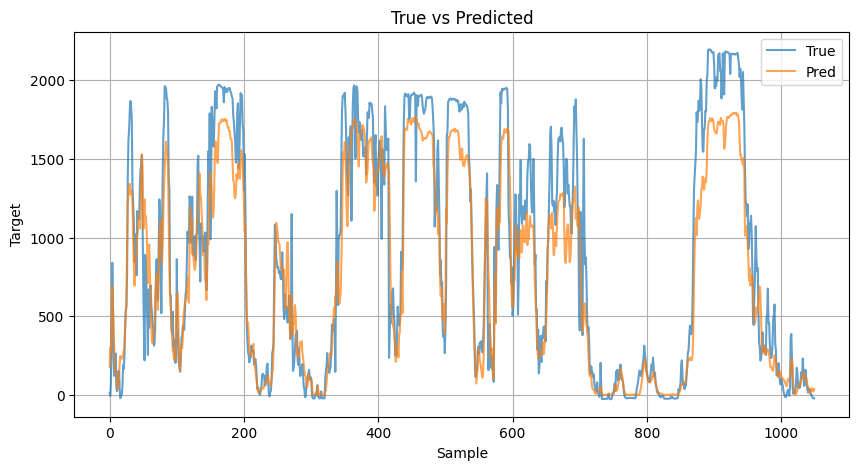

In [148]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred_val, weights = model(X_val_t, E_val_t)

y_true = y_val_t.cpu().numpy().flatten()
y_pred = y_pred_val.cpu().numpy().flatten()

plt.figure(figsize=(10, 5))
plt.plot(y_true, label="True", alpha=0.7)
plt.plot(y_pred, label="Pred", alpha=0.7)
plt.legend()
plt.title("True vs Predicted")
plt.xlabel("Sample")
plt.ylabel("Target")
plt.grid()
plt.show()

In [ ]:
def mae_relative(y_true, y_pred):
    # MAE = Mean Average Error
    mae = np.mean(np.abs(y_pred - y_true))
    mean_target = np.mean(y_true)
    return 100 * mae / mean_target

mae_rel = mae_relative(y_true, y_pred)
mae = np.mean(np.abs(y_pred - y_true))

In [154]:

print(f"MAE: {mae}")
print(f"MAE Relative: {mae_rel}%")

MAE: 185.86038208007812
MAE Relative: 21.023902893066406%


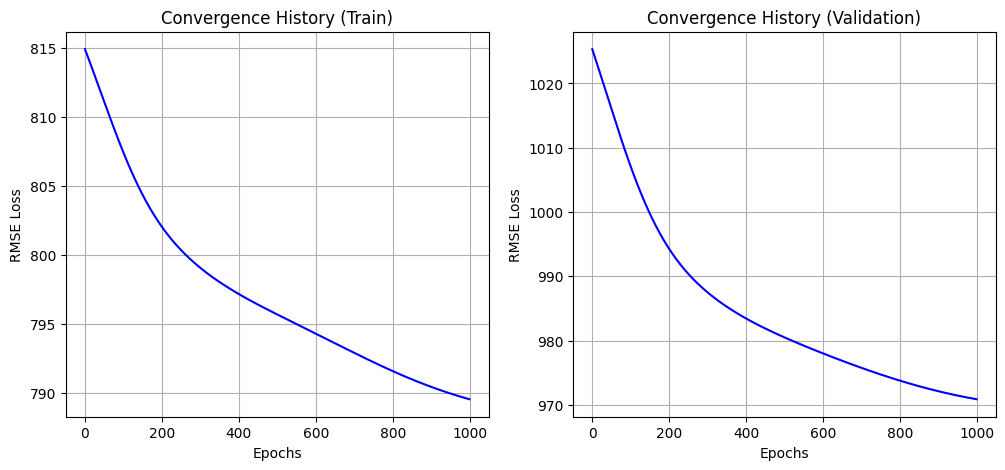

In [150]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 5))

# Plot 1: Learning Curve
plt.subplot(1, 2, 1)
plt.plot(history_train_loss, color='blue', label='Train Loss')
plt.title("Convergence History (Train)")
plt.xlabel("Epochs")
plt.ylabel("RMSE Loss")
plt.grid(True)

# Plot 2: Validation Curve
plt.subplot(1, 2, 2)
plt.plot(history_val_loss, color='blue', label='Train Loss')
plt.title("Convergence History (Validation)")
plt.xlabel("Epochs")
plt.ylabel("RMSE Loss")
plt.grid(True)

# 3. Predictions vs. Experts

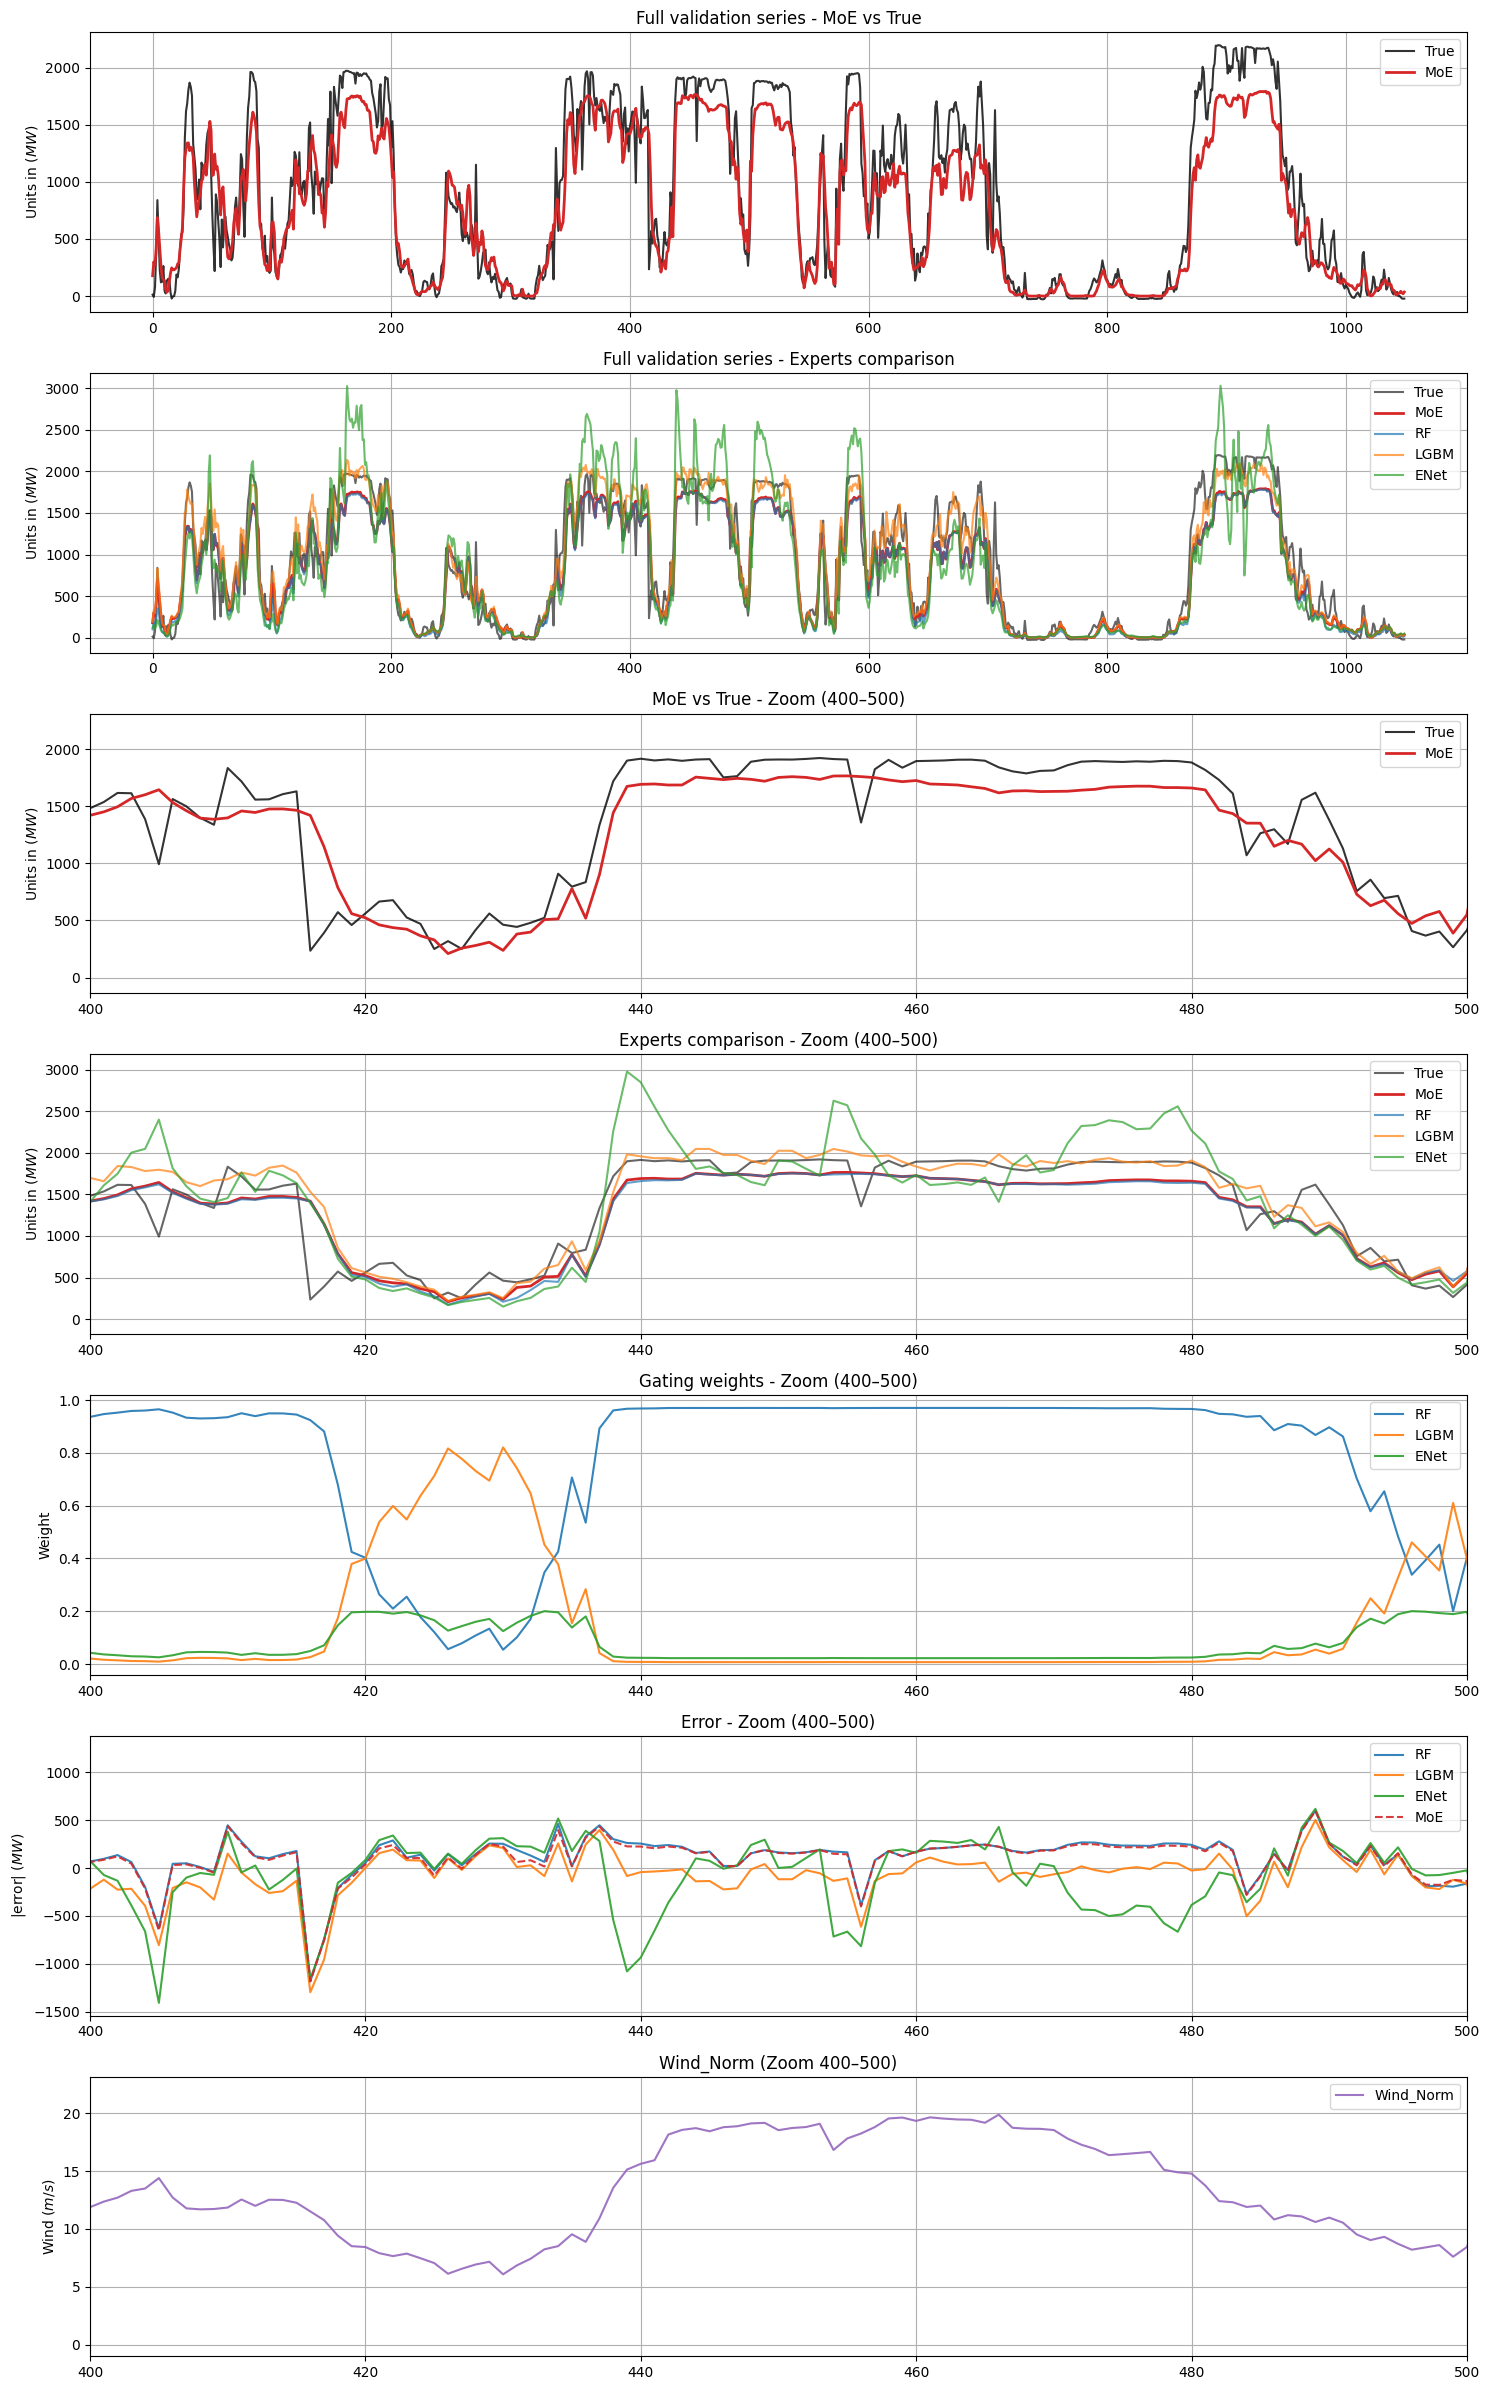

In [151]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred_val, w_val  = model(X_val_t, E_val_t)

y_true = y_val_t.cpu().numpy()
y_pred = y_pred_val.cpu().numpy()
weights = w_val.cpu().numpy()

# randomforest
exp_1 = E_val.to_numpy()[:,0]
# lgbm
exp_2 = E_val.to_numpy()[:,1]
# elasticnet
exp_3 = E_val.to_numpy()[:,2]

# windnorm
wind_norm = X_test.to_numpy()


start, end = 400,500

err_moe  = np.abs(y_true - y_pred.squeeze())
err_rf   = np.abs(y_true - exp_1)
err_lgbm = np.abs(y_true - exp_2)
err_enet = np.abs(y_true - exp_3)

err_moe  = (y_true - y_pred.squeeze())
err_rf   = (y_true - exp_1)
err_lgbm = (y_true - exp_2)
err_enet = (y_true - exp_3)

# ----------------------------------
# COLOR MAP
# ----------------------------------
colors = {
    "true": "black",
    "moe": "tab:red",
    "rf": "tab:blue",
    "lgbm": "tab:orange",
    "enet": "tab:green",
    "wind": "tab:purple"
}

wind_norm = X_val["Wind_Norm"].to_numpy()

plt.figure(figsize=(15, 24))

# ----------------------------------
# 1 — True vs MoE
# ----------------------------------
plt.subplot(7, 1, 1)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.8)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.legend()
plt.ylabel("Units in $(MW)$")
plt.title("Full validation series - MoE vs True")
plt.grid()

# ----------------------------------
# 2 — All models
# ----------------------------------
plt.subplot(7, 1, 2)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.6)
plt.title("Full series (Experts comparison)")
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)

plt.plot(exp_1, label="RF", color=colors["rf"], alpha=0.7)
plt.plot(exp_2, label="LGBM", color=colors["lgbm"], alpha=0.7)
plt.plot(exp_3, label="ENet", color=colors["enet"], alpha=0.7)

plt.legend()
plt.ylabel("Units in $(MW)$")
plt.title("Full validation series - Experts comparison")
plt.grid()

# ----------------------------------
# 3 — Zoom MoE
# ----------------------------------
plt.subplot(7, 1, 3)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.8)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.legend()
plt.title(f"MoE vs True - Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("Units in $(MW)$")
plt.grid()

# ----------------------------------
# 4 — Zoom all models
# ----------------------------------
plt.subplot(7, 1, 4)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.6)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)

plt.plot(exp_1, label="RF", color=colors["rf"], alpha=0.7)
plt.plot(exp_2, label="LGBM", color=colors["lgbm"], alpha=0.7)
plt.plot(exp_3, label="ENet", color=colors["enet"], alpha=0.7)

plt.legend()
plt.title(f"Experts comparison - Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("Units in $(MW)$")
plt.grid()

# ----------------------------------
# 5 — Weights
# ----------------------------------
plt.subplot(7, 1, 5)
plt.plot(weights[:, 0], label="RF", color=colors["rf"], alpha=0.9)
plt.plot(weights[:, 1], label="LGBM", color=colors["lgbm"], alpha=0.9)
plt.plot(weights[:, 2], label="ENet", color=colors["enet"], alpha=0.9)

plt.legend()
plt.title(f"Gating weights - Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("Weight")
plt.grid()


# ----------------------------------
# 6 — Absolute errors
# ----------------------------------
plt.subplot(7, 1, 6)
plt.plot(err_rf, label="RF", color=colors["rf"], alpha=0.9)
plt.plot(err_lgbm, label="LGBM", color=colors["lgbm"], alpha=0.9)
plt.plot(err_enet, label="ENet", color=colors["enet"], alpha=0.9)
plt.plot(err_moe, label="MoE", color=colors["moe"], alpha=0.9, linestyle = 'dashed')

plt.legend()
plt.title(f"Error - Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("|error| $(MW)$")
plt.grid()


# ----------------------------------
# 7 — Wind feature
# ----------------------------------
plt.subplot(7, 1, 7)
plt.plot(wind_norm, label="Wind_Norm", color=colors["wind"], alpha=0.9)

plt.legend()
plt.title(f"Wind_Norm (Zoom {start}–{end})")
plt.xlim((start, end))
plt.ylabel("Wind $(m/s)$")
plt.grid()

# ----------------------------------
# FINAL DISPLAY
# ----------------------------------
plt.tight_layout()
plt.show()

In [152]:
start, end = 400, 600

err_moe  = np.abs(y_true - y_pred.squeeze())
err_rf   = np.abs(y_true - exp_1)
err_lgbm = np.abs(y_true - exp_2)
err_enet = np.abs(y_true - exp_3)


print(y_true.shape)
print(y_pred.squeeze().shape)

(1050,)
(1050,)


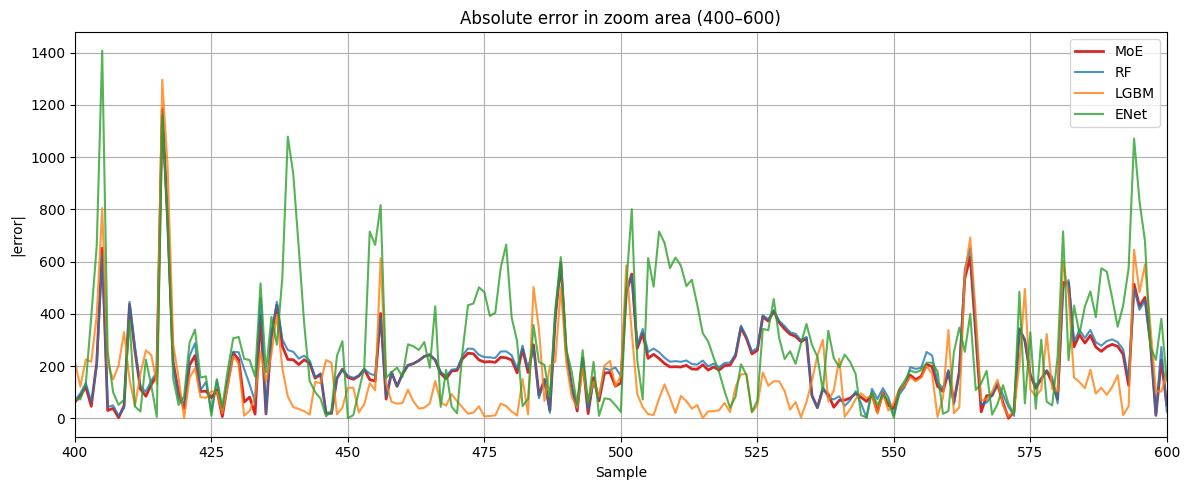

In [153]:

plt.figure(figsize=(12, 5))
plt.plot(err_moe,  label="MoE",  color="tab:red",    linewidth=2)
plt.plot(err_rf,   label="RF",   color="tab:blue",   alpha=0.8)
plt.plot(err_lgbm, label="LGBM", color="tab:orange", alpha=0.8)
plt.plot(err_enet, label="ENet", color="tab:green",  alpha=0.8)

plt.title("Absolute error in zoom area (400–600)")
plt.xlabel("Sample")
plt.ylabel("|error|")
plt.legend()
plt.grid()
plt.xlim((start, end))
plt.tight_layout()
plt.show()